In [1]:
%load_ext autoreload
%autoreload 2

# Confidence Distribution Construction

## INTRO & SETTINGS

The goal of this tutorial is to show the capabilities of `lf2i` and the `posterior` test statistic with a simple example: inferring the mean $\theta \in \mathbb{R}^{2}$ of a Gaussian model with fixed covariance, and a Gaussian prior distribution

$$\boldsymbol{\theta} \sim \mathcal{N}(\mathbb{0}, 0.1 \cdot \mathbb{I}), \\ \text{ } \mathbf{X}|\boldsymbol{\theta} \sim \mathcal{N}(\boldsymbol{\theta}, 0.01 \cdot \mathbb{I})$$

In addition, we assume that we only observe one sample for each true $\boldsymbol{\theta}$, i.e., $n=1$.
For this tutorial, we leverage a posterior estimator (`SNPE` from the `sbi` library) as the main underlying inferential model.

In [2]:
# SETTINGS

LIKELIHOOD_COV = 0.01
PRIOR_LOC = 0
PRIOR_COV = 0.1

PARAM_DIM = 2
DATA_DIM = 2
BATCH_SIZE = 1  # assume we get to see only one observed sample for each “true” parameter
PARAM_SPACE_BOUNDS = {'low': -1.5, 'high': 1.5}  # a grid of points over [low, high]^(param_dim) is used to construct confidence sets

CONFIDENCE_LEVEL = 0.90

## DATA GENERATION

Let's start from the simulator, which is used internally to generate data needed to
1. estimate the test statistics;
2. estimate the critical values; and
3. diagnose the constructed confidence regions

In [3]:
from lf2i.simulator.gaussian import GaussianMean

In [4]:
simulator = GaussianMean(
    likelihood_cov=LIKELIHOOD_COV,
    prior='gaussian',
    poi_space_bounds=PARAM_SPACE_BOUNDS,
    poi_grid_size=10_000,
    poi_dim=PARAM_DIM, 
    data_dim=DATA_DIM,
    batch_size=BATCH_SIZE,
    prior_kwargs={'loc': PRIOR_LOC, 'cov': PRIOR_COV}
)

In [40]:
b_params, b_samples = simulator.simulate_for_test_statistic(20_000, estimation_method='likelihood')
b_prime_params, b_prime_samples = simulator.simulate_for_critical_values(10_000)

b_samples = b_samples.reshape(-1, DATA_DIM)
b_prime_samples = b_prime_samples.reshape(-1, DATA_DIM)

#### Observations

For simplicity, let's use the simulator to generate two “observed” samples from the true likelihood: one consistent with the prior ($\boldsymbol{\theta}^{\star} = [0, 0]$) and one not ($\boldsymbol{\theta}^{\star} = [-1.45, 1.45]$)

In [37]:
import torch

true_param_consistent, true_param_notconsistent = torch.Tensor([0, 0]), torch.Tensor([-1.45, 1.45])
observed_x_consistent = simulator.likelihood(true_param_consistent).sample(sample_shape=(BATCH_SIZE, ))
observed_x_notconsistent = simulator.likelihood(true_param_notconsistent).sample(sample_shape=(BATCH_SIZE, ))

## A FREQUENTIST CONFIDENCE PROCEDURE

Assume we want to do inference on the Gaussian mean by estimating its posterior distribution. `Posterior` allows to leverage a neural posterior estimator like `SNPE` to obtain a confidence region for the parameter of interest that is guaranteed to have the desired level of coverage regardless of 
1. the prior distribution;
2. the true value of the parameter;
3. the size of the observed sample

The prediction algorithm can be pre-trained or not. The example below assumes the estimator has not been trained yet

**Note**: We require that posterior-based methods receive estimators whose interface matches one of `AbstractNeuralPosterior` or `AbstractNeuralPosteriorTrainer` from the `lf2i.estimators.base_posteriors` module.

In [38]:
from lf2i.inference import LF2I
from lf2i.test_statistics import Posterior
from lf2i.utils.other_methods import hpd_region
from lf2i.plot.parameter_regions import (
    plot_parameter_regions,
    plot_parameter_intervals,
    parameter_regions_pairplot,
)

from sbi.inference import SNPE

In [44]:
lf2i = LF2I(
    test_statistic=Posterior(
        estimator=SNPE(),
        poi_dim=PARAM_DIM
    )
)

Note that for this example we are using the simulator to obtain training datasets. If one has pre-simulated datasets, they can be given as inputs directly to the `inference` method.

As we proceed with the construction using p-values, we will rely on the default neural network-based CDF estimator, a semiparametric model proscribing the sigmoid distribution to the conditional sampling distribution of the posterior test statistic for each condition, $\theta$.

In [45]:
confidence_region = lf2i.inference(
    x=torch.vstack((observed_x_consistent, observed_x_notconsistent)).reshape(-1, DATA_DIM),
    evaluation_grid=simulator.poi_grid,
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='p-values',
    calibration_model='nn',
    T=(b_params, b_samples),
    T_prime=(b_prime_params, b_prime_samples)
)

Estimating test statistic ...
 Neural network successfully converged after 72 epochs.
Calibration ...


Evaluating posterior for 10000 points ...: 100%|██████████| 10000/10000 [05:22<00:00, 30.99it/s] 



Retraining calibration...
  [calibration] CDF estimator — augment_kwargs ignored.
  [calibration] CDF estimator: fitting on 10000 raw (T, θ) pairs.

Constructing confidence sets ...


Evaluating posterior for 2 points ...: 100%|██████████| 2/2 [00:00<00:00,  5.82it/s]



Computing p-values...

Creating set 0...


### Observation consistent with the prior

LF2I Confidence Region

/jet/home/jcarzon/probabilistic-regression/submodule/lf2i/src/lf2i/plot/parameter_regions.py:427: UserWarning: Contour might be unreliable if alpha is not chosen properly. Please plot scatter as well, and choose alpha appropriately (try from 1 to 20).
  warnings.warn("Contour might be unreliable if alpha is not chosen properly. Please plot scatter as well, and choose alpha appropriately (try from 1 to 20).")


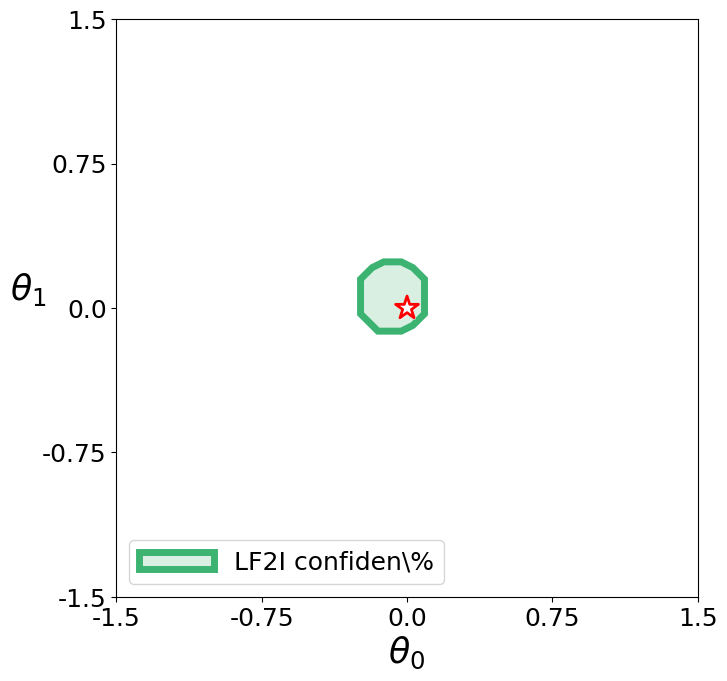

In [46]:
# The red star in the plot is the true parameter

plot_parameter_regions(
    confidence_region[0],
    param_dim=PARAM_DIM,
    true_parameter=true_param_consistent,
    param_names=[r'$\theta_0$', r'$\theta_1$'],
    parameter_space_bounds={r'$\theta_0$': simulator.poi_space_bounds, r'$\theta_1$': simulator.poi_space_bounds},
    alpha_shape=True,  # contour,
    alpha=2,  # hyperparameter for contour (the lower, the more it converges to a convex hull)
    scatter=False,  # don't plot evaluation points
    figsize=(7.5, 7.5),
    colors=['mediumseagreen'],
    region_names=['LF2I confidence set']
)

Posterior Credible Region

/jet/home/jcarzon/probabilistic-regression/submodule/lf2i/src/lf2i/plot/parameter_regions.py:427: UserWarning: Contour might be unreliable if alpha is not chosen properly. Please plot scatter as well, and choose alpha appropriately (try from 1 to 20).
  warnings.warn("Contour might be unreliable if alpha is not chosen properly. Please plot scatter as well, and choose alpha appropriately (try from 1 to 20).")


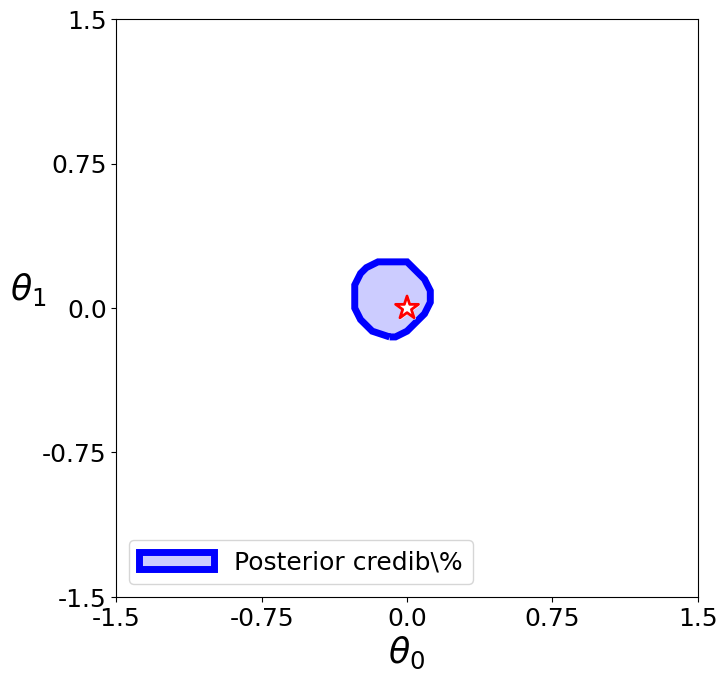

In [47]:
plot_parameter_regions(
    hpd_region(
        posterior=lf2i.test_statistic.estimator,
        param_grid=simulator.poi_grid,
        x=observed_x_consistent,
        credible_level=CONFIDENCE_LEVEL
    )[1],
    param_dim=PARAM_DIM,
    true_parameter=true_param_consistent,
    param_names=[r'$\theta_0$', r'$\theta_1$'],
    parameter_space_bounds={r'$\theta_0$': simulator.poi_space_bounds, r'$\theta_1$': simulator.poi_space_bounds},
    alpha_shape=True,  # contour,
    alpha=2,  # hyperparameter for contour (the lower, the more it converges to a convex hull)
    scatter=False,  # don't plot evaluation points
    figsize=(7.5, 7.5),
    colors=['blue'],
    region_names=['Posterior credible set']
)

### Observation *not* consistent with the prior

LF2I Confidence Region

/jet/home/jcarzon/probabilistic-regression/submodule/lf2i/src/lf2i/plot/parameter_regions.py:427: UserWarning: Contour might be unreliable if alpha is not chosen properly. Please plot scatter as well, and choose alpha appropriately (try from 1 to 20).
  warnings.warn("Contour might be unreliable if alpha is not chosen properly. Please plot scatter as well, and choose alpha appropriately (try from 1 to 20).")


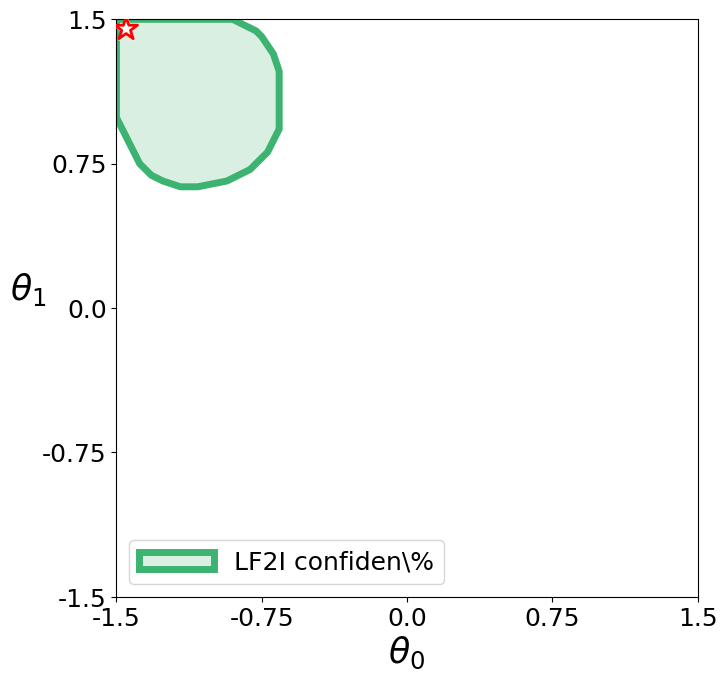

In [48]:
plot_parameter_regions(
    confidence_region[1],
    param_dim=PARAM_DIM,
    true_parameter=true_param_notconsistent,
    param_names=[r'$\theta_0$', r'$\theta_1$'],
    parameter_space_bounds={r'$\theta_0$': simulator.poi_space_bounds, r'$\theta_1$': simulator.poi_space_bounds},
    alpha_shape=True,  # contour,
    alpha=2,  # hyperparameter for contour (the lower, the more it converges to a convex hull)
    scatter=False,  # don't plot evaluation points
    figsize=(7.5, 7.5),
    colors=['mediumseagreen'],
    region_names=['LF2I confidence set']
)

Posterior Credible Region

/jet/home/jcarzon/probabilistic-regression/submodule/lf2i/src/lf2i/plot/parameter_regions.py:427: UserWarning: Contour might be unreliable if alpha is not chosen properly. Please plot scatter as well, and choose alpha appropriately (try from 1 to 20).
  warnings.warn("Contour might be unreliable if alpha is not chosen properly. Please plot scatter as well, and choose alpha appropriately (try from 1 to 20).")


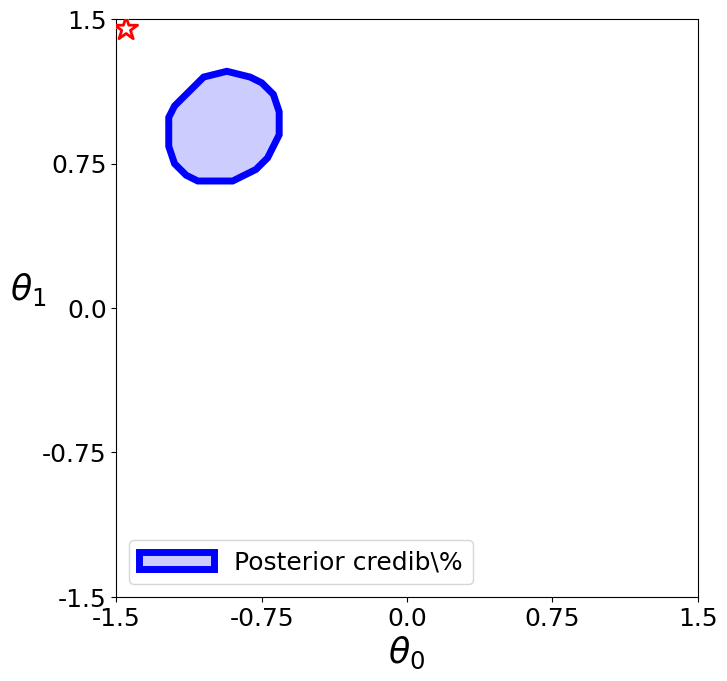

In [49]:
plot_parameter_regions(
    hpd_region(
        posterior=lf2i.test_statistic.estimator,
        param_grid=simulator.poi_grid,
        x=observed_x_notconsistent,
        credible_level=CONFIDENCE_LEVEL
    )[1],
    param_dim=PARAM_DIM,
    true_parameter=true_param_notconsistent,
    param_names=[r'$\theta_0$', r'$\theta_1$'],
    parameter_space_bounds={r'$\theta_0$': simulator.poi_space_bounds, r'$\theta_1$': simulator.poi_space_bounds},
    alpha_shape=True,  # contour,
    alpha=2,  # hyperparameter for contour (the lower, the more it converges to a convex hull)
    scatter=False,  # don't plot evaluation points
    figsize=(7.5, 7.5),
    colors=['blue'],
    region_names=['Posterior credible set']
)

# ESTIMATED COVERAGE

In [64]:
from lf2i.plot.coverage_diagnostics import coverage_probability_plot

T_double_prime = simulator.simulate_for_diagnostics(10_000)

#### Posterior Credible Regions

Note that for this example we are using the simulator to obtain training datasets. If one has pre-simulated datasets, they can be given as inputs directly to the `inference` method.

In [67]:
# this will take a few minutes because it has to compute a HPD credible region for each pair of (theta, x) in the simulated set
# the code is parallelized, but one can make it faster by decreasing the argument num_p_levels, which controls the number of level sets examined to construct the HPD region
# note that this might cause the credibility level of the HPD region to be only approximately equal to CONFIDENCE LEVEL
diagnostic_estimator, parameters, mean_proba, upper_proba, lower_proba, sizes = lf2i.coverage(
    region_type='posterior',
    T_double_prime=T_double_prime,
    evaluation_grid=simulator.poi_grid.reshape(-1, PARAM_DIM),
    confidence_level=CONFIDENCE_LEVEL,
    posterior_estimator=lf2i.test_statistic.estimator,
    n_jobs=8
)

Computing indicators for 10000 credible regions: 100%|██████████| 10000/10000 [06:27<00:00, 25.83it/s]


Coverage of posterior credible regions can be very erratic: they tend to overcover close to the “bulk” of the prior and severely undercover far from it. The correct level here is 90%

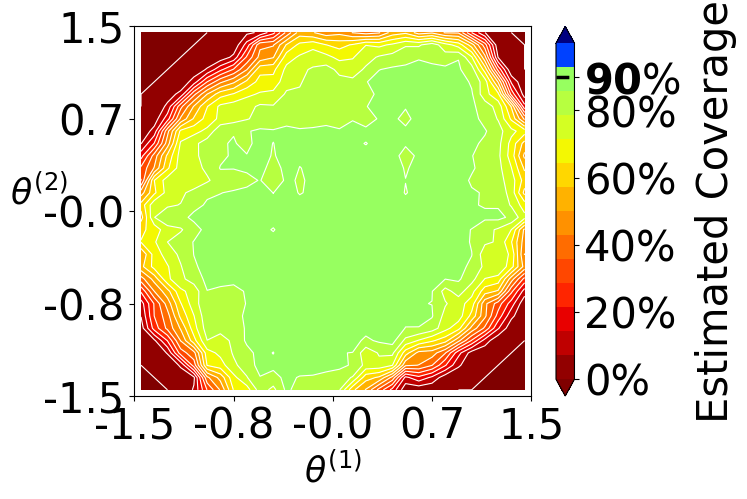

In [68]:
coverage_probability_plot(
    parameters=parameters,
    coverage_probability=mean_proba, 
    upper_proba=None,
    lower_proba=None,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=PARAM_DIM,
    figsize=(12, 12)
)

#### LF2I Confidence Regions

Note that for this example we are using the simulator to obtain training datasets. If one has pre-simulated datasets, they can be given as inputs directly to the `inference` method.

In [65]:
diagnostic_estimator, parameters, mean_proba, upper_proba, lower_proba = lf2i.diagnostics(
    region_type='lf2i',
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='p-values',
    T_double_prime=T_double_prime,
)

/var/tmp/ipykernel_84439/243216418.py:1: DeprecationWarning: LF2I.diagnostics() is deprecated and will be removed in a future release. Use LF2I.coverage() instead.
  diagnostic_estimator, parameters, mean_proba, upper_proba, lower_proba = lf2i.diagnostics(
Evaluating posterior for 10000 points ...:   0%|          | 0/10000 [00:00<?, ?it/s]

Evaluating posterior for 10000 points ...: 100%|██████████| 10000/10000 [02:04<00:00, 80.19it/s]


Coverage of LF2I is approximately 90% everywhere, as desired

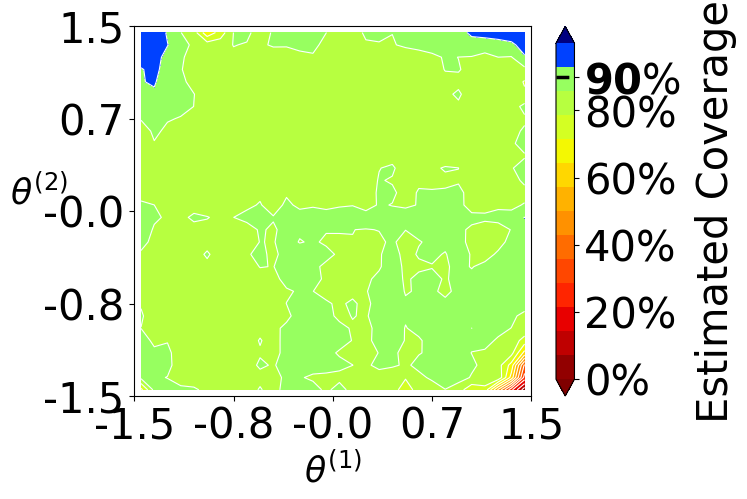

In [66]:
coverage_probability_plot(
    parameters=parameters,
    coverage_probability=mean_proba, 
    upper_proba=None,
    lower_proba=None,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=PARAM_DIM,
    figsize=(12, 10)
)